# Тестовая работа по задаче классификация на датасете Titanic - Machine Learning from Disaster

## Задача
Цель задачи с помощью машинного обучения создать модель, которая предскажет, кто из пассажиров «Титаника» выжил.

## Знакомство с данными


In [2]:
# Загрузка базовых библиотек для знакомства с данными 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Загружаем данные, датасет сразу разделен на test и train
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Увидел пропуски в данных, хочу понять сколько их
df_train.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df_train.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [9]:
df_train.groupby('Survived')['Survived'].count()

Survived
0    549
1    342
Name: Survived, dtype: int64

Вывод по базовому анализу:

Датасет содержит 891 запись и 12 признаков.
Обнаружены пропуски: в признаке Age отсутствует ~20% данных, в Cabin — ~77% (практически полностью пуст), в Embarked — 2 пропуска.
Типы данных корректны (за исключением Age, которая имеет тип float из-за NaN).
В целевой переменной Survived наблюдается дисбаланс классов: 62% пассажиров погибло, 38% выжило.

## Изучение признаков и их влияние на Survived

In [10]:
categorical_cols = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
for col in categorical_cols:
    surv_rate = df_train.groupby(col)['Survived'].value_counts(normalize=True).unstack()
    if 1 in surv_rate.columns:
        surv_rate = surv_rate[1].sort_values(ascending=False)
        print(f"\n{col} → Survive Rate:")
        print(surv_rate.round(3))


Pclass → Survive Rate:
Pclass
1    0.630
2    0.473
3    0.242
Name: 1, dtype: float64

Sex → Survive Rate:
Sex
female    0.742
male      0.189
Name: 1, dtype: float64

SibSp → Survive Rate:
SibSp
1    0.536
2    0.464
0    0.345
3    0.250
4    0.167
5      NaN
8      NaN
Name: 1, dtype: float64

Parch → Survive Rate:
Parch
3    0.600
1    0.551
2    0.500
0    0.344
5    0.200
4      NaN
6      NaN
Name: 1, dtype: float64

Embarked → Survive Rate:
Embarked
C    0.554
Q    0.390
S    0.337
Name: 1, dtype: float64


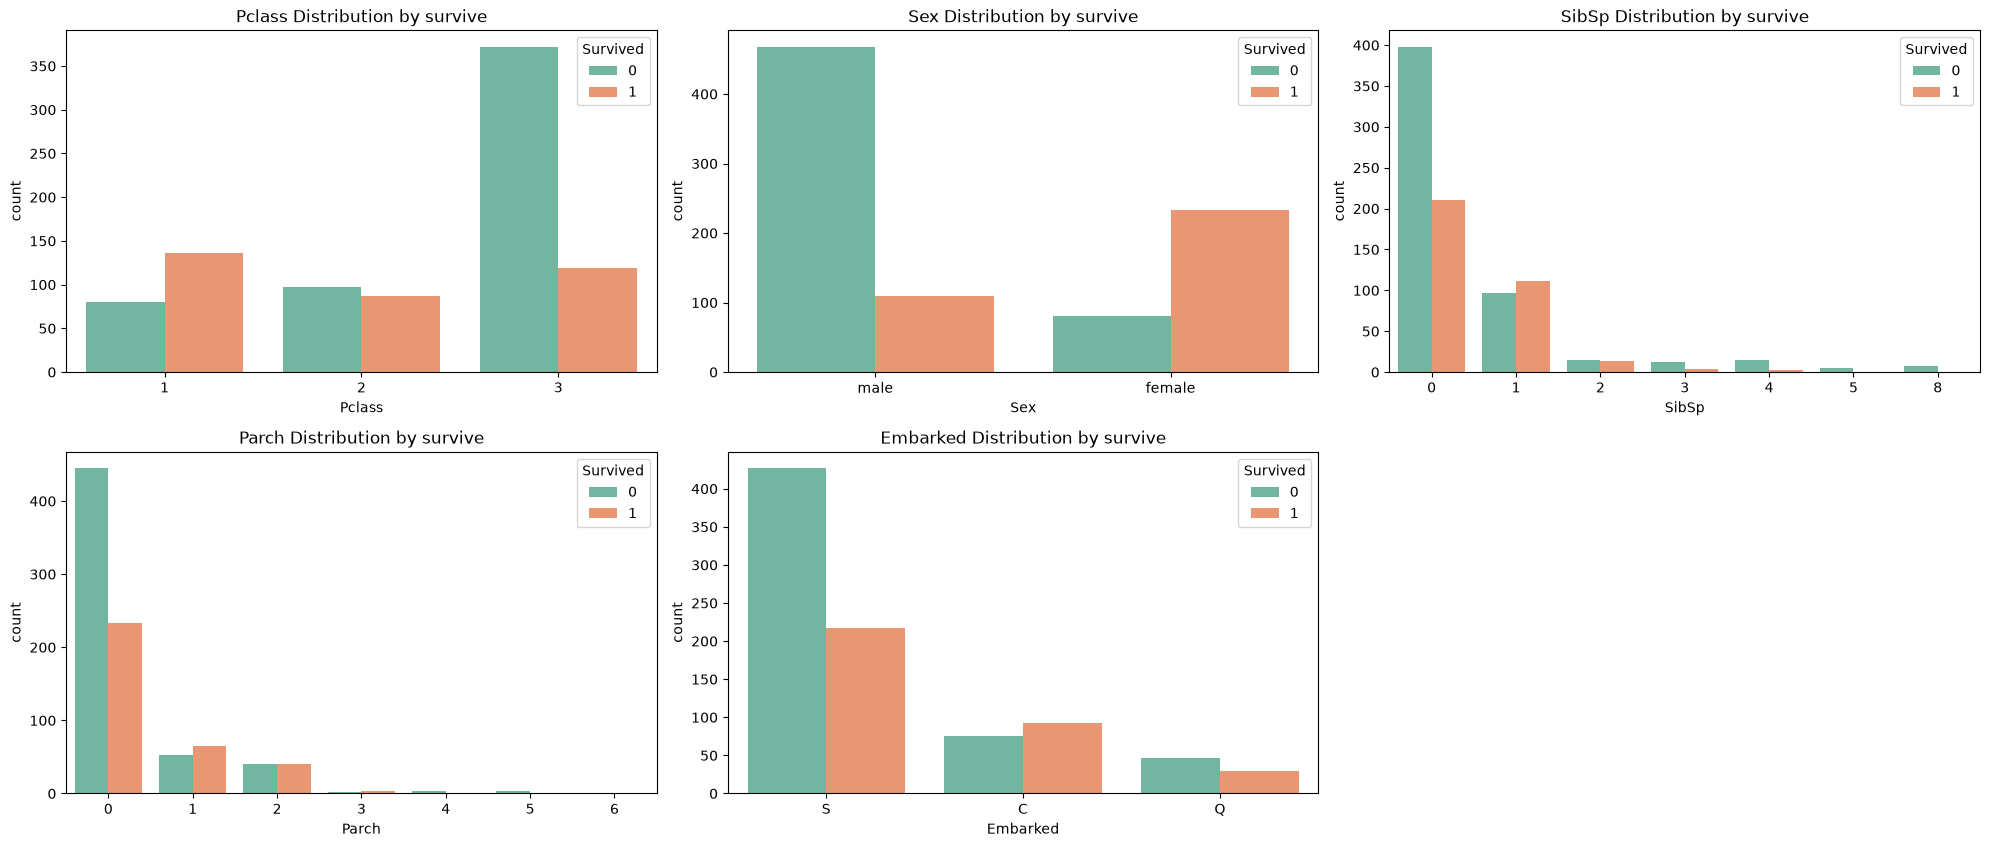

In [11]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(6, 3, i)
    sns.countplot(data=df_train, x=col, hue='Survived', palette='Set2')
    plt.title(f'{col} Distribution by survive')
    plt.tight_layout()


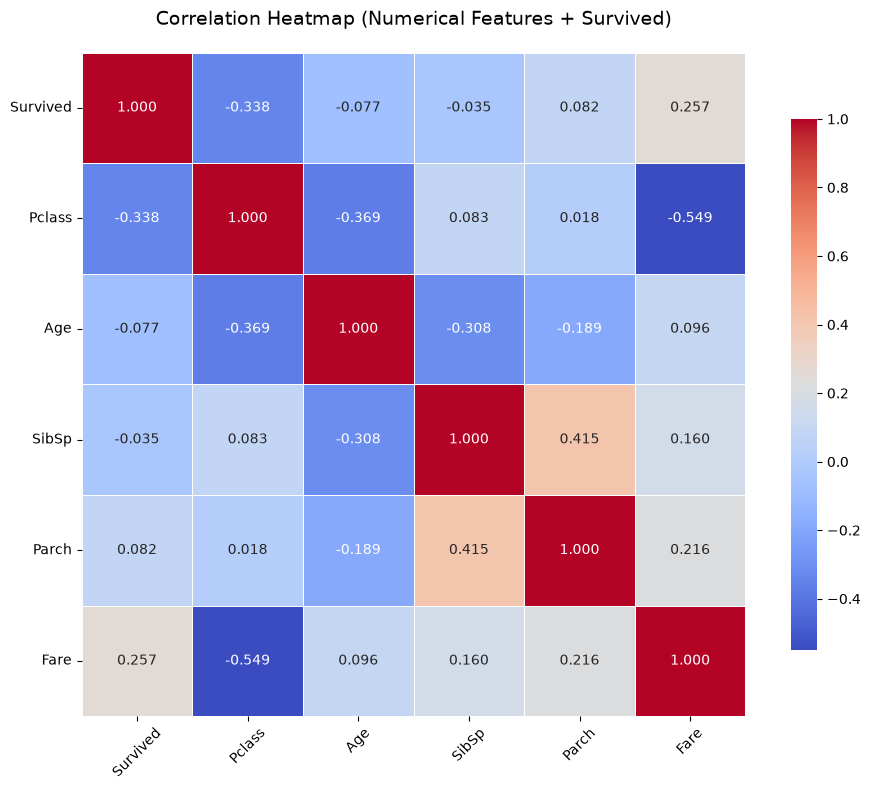

In [12]:
corr_matrix = df_train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numerical Features + Survived)', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

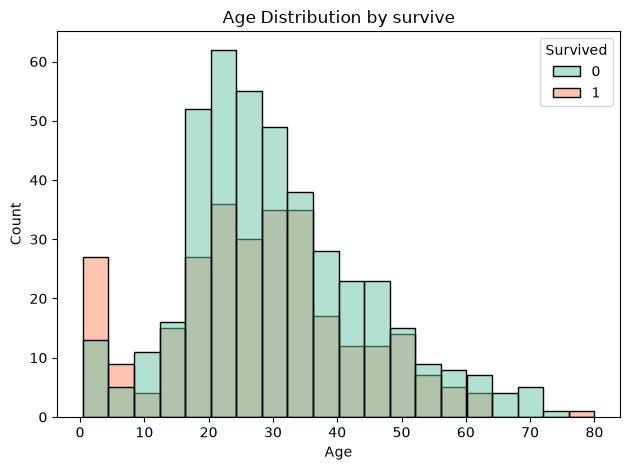

In [13]:
sns.histplot(data=df_train, x='Age', hue='Survived', palette='Set2')
plt.title(f'Age Distribution by survive')
plt.tight_layout()

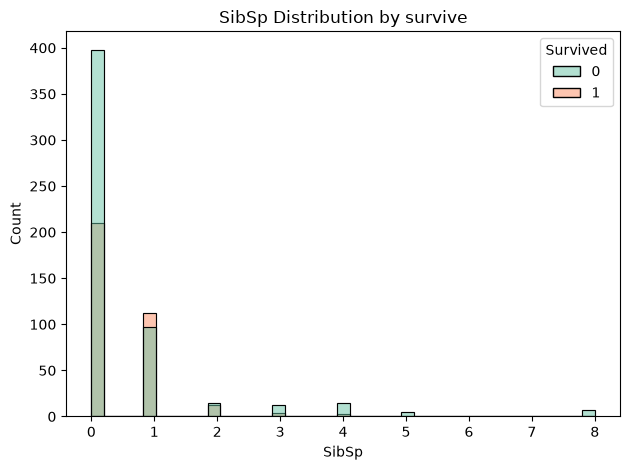

In [14]:
sns.histplot(data=df_train, x='SibSp', hue='Survived', palette='Set2')
plt.title(f'SibSp Distribution by survive')
plt.tight_layout()

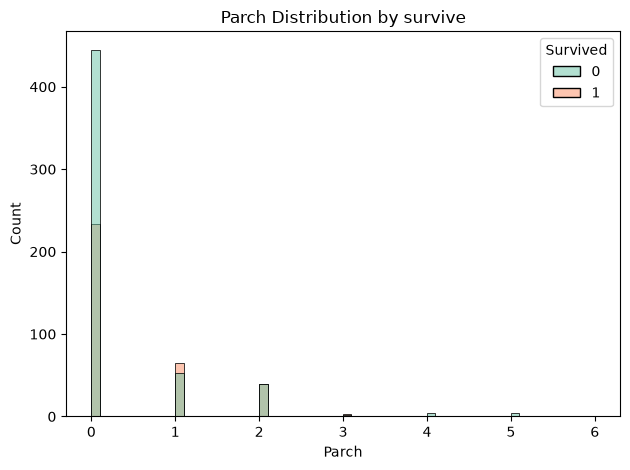

In [15]:
sns.histplot(data=df_train, x='Parch', hue='Survived', palette='Set2')
plt.title(f'Parch Distribution by survive')
plt.tight_layout()

Вывод по влиянию признаков:

Пол (Sex) — сильнейший предиктор: выживаемость женщин составляет 74.2%, мужчин — лишь 18.9%.
Класс билета (Pclass) — имеет строгую обратную корреляцию с выживаемостью (1 класс — 63%, 3 класс — 24%).
Семья (SibSp, Parch) — распределение неравномерное. Целесообразно объединить их в единый признак Family_Size для оценки общего размера семьи.
Имя (Name) — содержит полезное обращение (Title: Mr, Mrs, Miss, Master), которое отражает пол, возраст и социальный статус. Извлечение этого признака может быть более полезным, чем исходные данные о родственниках. Мультиколлинеарность с полом не критична для древовидных моделей.

In [16]:
# так как дальше будет обработка признаков, объеденим train и tast что бы изменения применились ко всем данным
df_train['is_train'] = 1
df_test['is_train'] = 0
df_full = pd.concat([df_train, df_test], ignore_index=True)

In [17]:
df_full['Title'] = df_full['Name'].str.extract(' ([A-Za-z]+)\.')
df_full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_train,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr


In [18]:
df_full.groupby('Title')['Survived'].count()

Title
Capt          1
Col           2
Countess      1
Don           1
Dona          0
Dr            7
Jonkheer      1
Lady          1
Major         2
Master       40
Miss        182
Mlle          2
Mme           1
Mr          517
Mrs         125
Ms            1
Rev           6
Sir           1
Name: Survived, dtype: int64

In [19]:
# Много редких признаков, объеденим 
df_full['Title'] = df_full['Title'].replace(['Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')
df_full['Title'] = df_full['Title'].replace(['Countess', 'Lady', 'Sir'], 'Royal')
df_full['Title'] = df_full['Title'].replace('Mlle', 'Miss')
df_full['Title'] = df_full['Title'].replace('Ms', 'Miss')
df_full['Title'] = df_full['Title'].replace('Mme', 'Mrs')


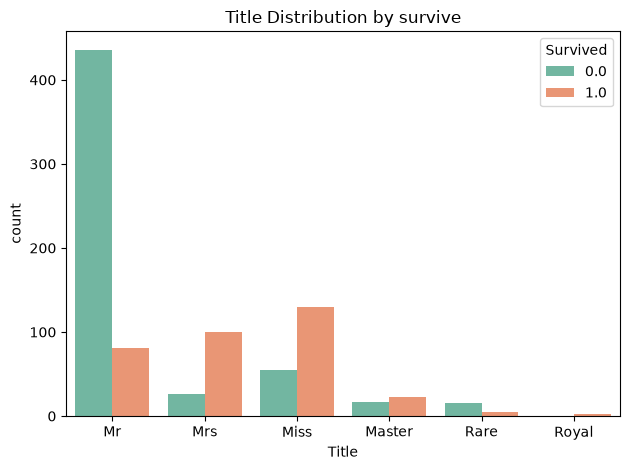

In [20]:
sns.countplot(data=df_full, x='Title', hue='Survived', palette='Set2')
plt.title(f'Title Distribution by survive')
plt.tight_layout()

In [21]:
surv_rate = df_full.groupby('Title')['Survived'].value_counts(normalize=True).unstack()
if 1 in surv_rate.columns:
    surv_rate = surv_rate[1].sort_values(ascending=False)
    print(f"\nTitle → Survive Rate:")
    print(surv_rate.round(3))


Title → Survive Rate:
Title
Royal     1.000
Mrs       0.794
Miss      0.703
Master    0.575
Rare      0.250
Mr        0.157
Name: 1.0, dtype: float64


Вывод по обращениям (Title):

Извлечение Title позволило выявить скрытые паттерны. Замужние женщины (Mrs) выживали чаще (79.4%), чем незамужние (Miss — 70.3%).
Мальчики (Master) имеют повышенный шанс на спасение (57.5%) по сравнению с взрослыми мужчинами.
Группы Royal и Rare слишком малочисленны для статистически значимых выводов, но Royal показывает 100% выживаемость. Редкие категории были объединены в группы 'Rare' и 'Royal' для избежания переобучения.

In [22]:
df_full['Family_Size'] = df_full['SibSp'] + df_full['Parch'] + 1

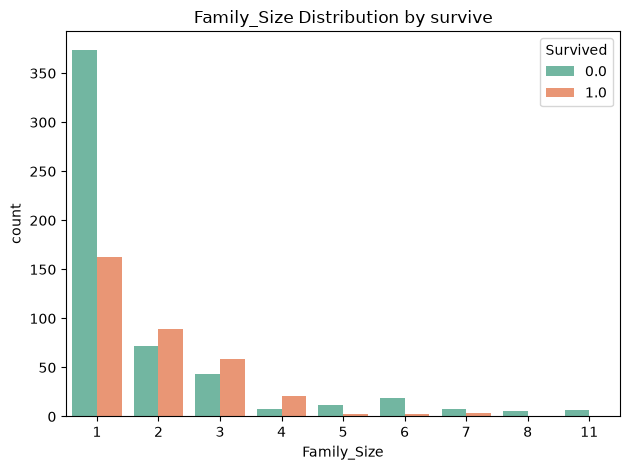

In [23]:
sns.countplot(data=df_full, x='Family_Size', hue='Survived', palette='Set2')
plt.title(f'Family_Size Distribution by survive')
plt.tight_layout()

## Подготовка данных 

In [24]:
# Заполним пропуски в Embarked популярным значением
df_full['Embarked'] = df_full['Embarked'].fillna('S')
df_full['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [25]:
# Заполним пропуски средним значением по группе Title что бы потерять меньше данных
train_part = df_full[df_full['is_train'] == 1]

age_medians_dict = train_part.groupby('Title')['Age'].median().to_dict()
df_full['Age'] = df_full['Age'].fillna(df_full['Title'].map(age_medians_dict))

df_full.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          0
is_train          0
Title             0
Family_Size       0
dtype: int64

In [26]:
df_full['Fare'] = df_full['Fare'].fillna(df_train['Fare'].mean())
df_full.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
is_train          0
Title             0
Family_Size       0
dtype: int64

In [27]:
df_full_base = df_full.copy()
# обработаем категориальные признки 
df_full['Sex'] = df_full['Sex'].map({'male': 0, 'female': 1})
df_full = pd.get_dummies(df_full, columns=['Title', 'Embarked'], drop_first=True)
df_full[['Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_Royal', 'Embarked_Q', 'Embarked_S']] = df_full[['Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_Royal', 'Embarked_Q', 'Embarked_S']].astype('int')

In [28]:
df_full = df_full.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)

In [29]:
df_full

,Survived,Pclass,Sex,Age,Fare,is_train,Family_Size,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_Royal,Embarked_Q,Embarked_S
0,0.0,3,0,22.0,7.2500,1,2,0,1,0,0,0,0,1
1,1.0,1,1,38.0,71.2833,1,2,0,0,1,0,0,0,0
2,1.0,3,1,26.0,7.9250,1,1,1,0,0,0,0,0,1
3,1.0,1,1,35.0,53.1000,1,2,0,0,1,0,0,0,1
4,0.0,3,0,35.0,8.0500,1,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,3,0,30.0,8.0500,0,1,0,1,0,0,0,0,1
1305,NaN,1,1,39.0,108.9000,0,1,0,0,0,1,0,0,0
1306,NaN,3,0,38.5,7.2500,0,1,0,1,0,0,0,0,1
1307,NaN,3,0,30.0,8.0500,0,1,0,1,0,0,0,0,1


In [30]:
X = df_full[df_full['is_train']==1].drop(['Survived', 'is_train'], axis=1).copy()
y = df_full[df_full['is_train']==1]['Survived']
test_kagel = df_full[df_full['is_train']==0].drop(['Survived', 'is_train'], axis=1).copy()

In [31]:
from sklearn.model_selection import train_test_split

# Теперь X_train и y_train - это те данные, где is_train == 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 12), (179, 12), (712,), (179,))

Вывод по предобработке:

Пропуски в Embarked заполнены модой (значение 'S').
Пропуски в Age заполнены медианным значением, сгруппированным по признаку Title (чтобы не закладывать средний возраст взрослого мужчины ребенку). Пропуск в Fare заполнен средним значением из train-выборки.
Выполнено One-Hot Encoding для категориальных признаков (Title, Embarked).
Из финального датасета удалены признаки, не несущие предиктивной силы для ML-модели: PassengerId, Name, Ticket, Cabin, а также исходные SibSp и Parch (заменены на Family_Size).

## Обучение модели 

In [32]:
# Загружаем библиотеки для ml
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import shap


In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("1. Training Baseline Model...")
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Baseline ROC-AUC (CV): {dummy_scores.mean():.4f} ± {dummy_scores.std():.4f}")

# линейная регрессия 
print("\n2. Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Logistic Regression ROC-AUC (CV): {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

# случайный лес
print("\n3. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Random Forest ROC-AUC (CV): {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

# XGBoost 
print("\n4. Training XGBoost...")
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"XGBoost ROC-AUC (CV): {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")


results = {
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC (CV Mean)': [dummy_scores.mean(), lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()],
    'ROC-AUC (CV Std)': [dummy_scores.std(), lr_scores.std(), rf_scores.std(), xgb_scores.std()]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON (5-Fold CV)")
print("="*60)
print(results_df)


1. Training Baseline Model...
Baseline ROC-AUC (CV): 0.5000 ± 0.0000

2. Training Logistic Regression...
Logistic Regression ROC-AUC (CV): 0.8695 ± 0.0213

3. Training Random Forest...
Random Forest ROC-AUC (CV): 0.8732 ± 0.0167

4. Training XGBoost...
XGBoost ROC-AUC (CV): 0.8879 ± 0.0078

MODEL PERFORMANCE COMPARISON (5-Fold CV)
                 Model  ROC-AUC (CV Mean)  ROC-AUC (CV Std)
0             Baseline             0.5000            0.0000
1  Logistic Regression             0.8695            0.0213
2        Random Forest             0.8732            0.0167
3              XGBoost             0.8879            0.0078


In [34]:
# 1. Задаем сетку параметров
param_grid = {
    'max_depth': [2, 3, 4, 5],           # Ищем оптимальную глубину
    'min_child_weight': [1, 3, 5, 10],   # Ищем ограничение листов
    'learning_rate': [0.01, 0.05, 0.1],  # Шаг обучения
    'n_estimators': [100, 200, 300],     # Количество деревьев
    'subsample': [0.8, 1.0],             # Доля данных для дерева
    'colsample_bytree': [0.8, 1.0],      # Доля фичей для дерева
}

# 2. Базовая модель
xgb_base = XGBClassifier(
    random_state=42, 
    eval_metric='logloss', 
    use_label_encoder=False
)

# 3. Инициализируем GridSearch
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,                    
    scoring='roc_auc',        
    n_jobs=-1,                
    verbose=1                 
)

print("Начинаем подбор гиперпараметров")
grid_search.fit(X_train, y_train)

# 4. Выводим лучшие результаты
print("\n" + "="*60)
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
print("="*60)
print(grid_search.best_params_)
print(f"\nЛучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

Начинаем подбор гиперпараметров
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

ЛУЧШИЕ ПАРАМЕТРЫ:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}

Лучший ROC-AUC на кросс-валидации: 0.8960


Вывод по первичному обучению XGBoost:

Хотя целевой метрикой Kaggle является Accuracy, из-за дисбаланса классов подбор гиперпараметров осуществлялся по метрике ROC-AUC.
Лучшая модель на кросс-валидации показала ROC-AUC = 0.8960. Оптимальные параметры: max_depth=4, learning_rate=0.1. Неглубокие деревья объясняются малым объемом обучающей выборки (защита от переобучения).
При проверке на отложенной выборке (X_test) модель показала Accuracy 0.8380, но Recall оказался низким (0.7391). Учитывая контекст задачи (спасение жизней), ложные отрицательные прогнозы критичны.

In [35]:
# Достаем лучшие параметры
best_params = grid_search.best_params_

# Создаем финальную модель
final_model = XGBClassifier(
    **best_params,              # Распаковываем словарь с лучшими параметрами
    random_state=42, 
    eval_metric='logloss', 
    use_label_encoder=False
)

final_model.fit(X_train, y_train)

y_val_pred = final_model.predict(X_test)
y_val_proba = final_model.predict_proba(X_test)[:, 1]

val_accuracy = accuracy_score(y_test, y_val_pred)
val_precision = precision_score(y_test, y_val_pred)
val_recall = recall_score(y_test, y_val_pred)
val_f1 = f1_score(y_test, y_val_pred)
val_roc_auc = roc_auc_score(y_test, y_val_proba)

print(f"Accuracy     : {val_accuracy:.4f}")
print(f"Precision    : {val_precision:.4f}")
print(f"Recall       : {val_recall:.4f}")
print(f"F1-Score     : {val_f1:.4f}")
print(f"ROC-AUC      : {val_roc_auc:.4f}")


Accuracy     : 0.8380
Precision    : 0.8226
Recall       : 0.7391
F1-Score     : 0.7786
ROC-AUC      : 0.8390


In [36]:
param_grid = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1.0, 1.5, 1.6, 2.0, 3.0] # Добавили поиск веса
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='recall', # Ищем максимальный Recall
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': 3.0}


В отличии от предыдущей модели эта уменьшила шаг обучения и уменьшила количество шагов, так же вес выбран очень высокий примерно x2 от реального дисбаланса, возможно она решила слишко сильно уменьшить остальные метрики в угоду recall

In [37]:
# Достаем лучшие параметры
best_recall = grid_search.best_params_

# Создаем финальную модель
recall_model = XGBClassifier(
    **best_recall,              # Распаковываем словарь с лучшими параметрами
    random_state=42, 
    eval_metric='logloss', 
    use_label_encoder=False
)

recall_model.fit(X_train, y_train)

y_val_pred = recall_model.predict(X_test)
y_val_proba = recall_model.predict_proba(X_test)[:, 1]

val_accuracy = accuracy_score(y_test, y_val_pred)
val_precision = precision_score(y_test, y_val_pred)
val_recall = recall_score(y_test, y_val_pred)
val_f1 = f1_score(y_test, y_val_pred)
val_roc_auc = roc_auc_score(y_test, y_val_proba)

print(f"Accuracy     : {val_accuracy:.4f}")
print(f"Precision    : {val_precision:.4f}")
print(f"Recall       : {val_recall:.4f}")
print(f"F1-Score     : {val_f1:.4f}")
print(f"ROC-AUC      : {val_roc_auc:.4f}")

Accuracy     : 0.7933
Precision    : 0.6818
Recall       : 0.8696
F1-Score     : 0.7643
ROC-AUC      : 0.8576


Вывод по оптимизации Recall:

Произведен повторный подбор гиперпараметров с оптимизацией по метрике Recall и использованием параметра scale_pos_weight для учета дисбаланса классов.
Использование веса scale_pos_weight=3.0 позволило увеличить Recall с 0.7391 до 0.8696 (+0.13). При этом Precision снизился с 0.8226 до 0.6818 (-0.14), а F1-score остался практически неизменным.
С точки зрения "бизнес-логики" (максимизация спасенных) вторая модель предпочтительнее, однако для отправки на Kaggle (где считается Accuracy) она не даст преимущества.


In [38]:
# 1. Переобучаем ТЕКУЩУЮ лучшую модель на 100% данных (X, y)
final_model.fit(X, y)

# 2. Делаем предсказания для Kaggle
kaggle_predictions = final_model.predict(test_kagel).astype(int)

# 3. Формируем файл
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': kaggle_predictions
})

# 4. Сохраняем
submission.to_csv('titanic_optimized.csv', index=False)
print("Файл готов к отправке на Kaggle!")

Файл готов к отправке на Kaggle!


Модель,на Kaggle показала 0.75837.
Это ниже базового эвристического правила (бенчмарка) "все женщины выжили", которое дает 0.76555.
Вывод: сложный Feature Engineering и настройка XGBoost привели к серьезному переобучению. Модель выучила паттерны train-выборки, которые не воспроизводятся на скрытом тесте Kaggle.

In [39]:
param_grid = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1.0, 1.5, 1.6, 2.0, 3.0] 
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy', # Ищем максимальный accuracy
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'scale_pos_weight': 1.0}


In [40]:
# Достаем лучшие параметры
best_accuracy = grid_search.best_params_

# Создаем финальную модель
accuracy_model = XGBClassifier(
    **best_accuracy,              # Распаковываем словарь с лучшими параметрами
    random_state=42, 
    eval_metric='logloss', 
    use_label_encoder=False
)

accuracy_model.fit(X_train, y_train)

y_val_pred = accuracy_model.predict(X_test)
y_val_proba = accuracy_model.predict_proba(X_test)[:, 1]

val_accuracy = accuracy_score(y_test, y_val_pred)
val_precision = precision_score(y_test, y_val_pred)
val_recall = recall_score(y_test, y_val_pred)
val_f1 = f1_score(y_test, y_val_pred)
val_roc_auc = roc_auc_score(y_test, y_val_proba)

print(f"Accuracy     : {val_accuracy:.4f}")
print(f"Precision    : {val_precision:.4f}")
print(f"Recall       : {val_recall:.4f}")
print(f"F1-Score     : {val_f1:.4f}")
print(f"ROC-AUC      : {val_roc_auc:.4f}")

Accuracy     : 0.8324
Precision    : 0.8095
Recall       : 0.7391
F1-Score     : 0.7727
ROC-AUC      : 0.8422


In [41]:
# 1. Переобучаем ТЕКУЩУЮ лучшую модель на 100% данных (X, y)
accuracy_model.fit(X, y)

# 2. Делаем предсказания для Kaggle
# X_kaggle = test_kagel.drop(['Survived', 'is_train'], axis=1)
kaggle_predictions = accuracy_model.predict(test_kagel).astype(int)

# 3. Формируем файл
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': kaggle_predictions
})

# 4. Сохраняем
submission.to_csv('titanic_accuracy_optimized.csv', index=False)
print("Файл готов к отправке на Kaggle!")

Файл готов к отправке на Kaggle!


На kagle получил 0.76555 то есть тоже самое что и когда if sex == 'female': survived = 1
Возникла гипотеза, что подбор параметров на X_train приводит к неоптимальным результатам на Kaggle.

In [42]:
param_grid = {
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1.0, 1.5, 1.6, 2.0, 3.0] 
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy', # Ищем максимальный accuracy
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)
print(f"Лучшие параметры: {grid_search.best_params_}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'scale_pos_weight': 1.0}


Произведен подбор гиперпараметров GridSearch на всем доступном датасете (X). Локальный CV-score повысился до 0.8507, параметры изменились (min_child_weight стал 3).

In [43]:
# Достаем лучшие параметры
best_accuracy = grid_search.best_params_

# Создаем финальную модель
accuracy_model = XGBClassifier(
    **best_accuracy,              # Распаковываем словарь с лучшими параметрами
    random_state=42, 
    eval_metric='logloss', 
    use_label_encoder=False
)
accuracy_model.fit(X, y)

# 2. Делаем предсказания для Kaggle
kaggle_predictions = accuracy_model.predict(test_kagel).astype(int)

# 3. Формируем файл
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': kaggle_predictions
})

# 4. Сохраняем
submission.to_csv('titanic_accuracy_optimized_v2.csv', index=False)
print("Файл готов к отправке на Kaggle!")

Файл готов к отправке на Kaggle!


SHAP shape for plot: (891, 12)


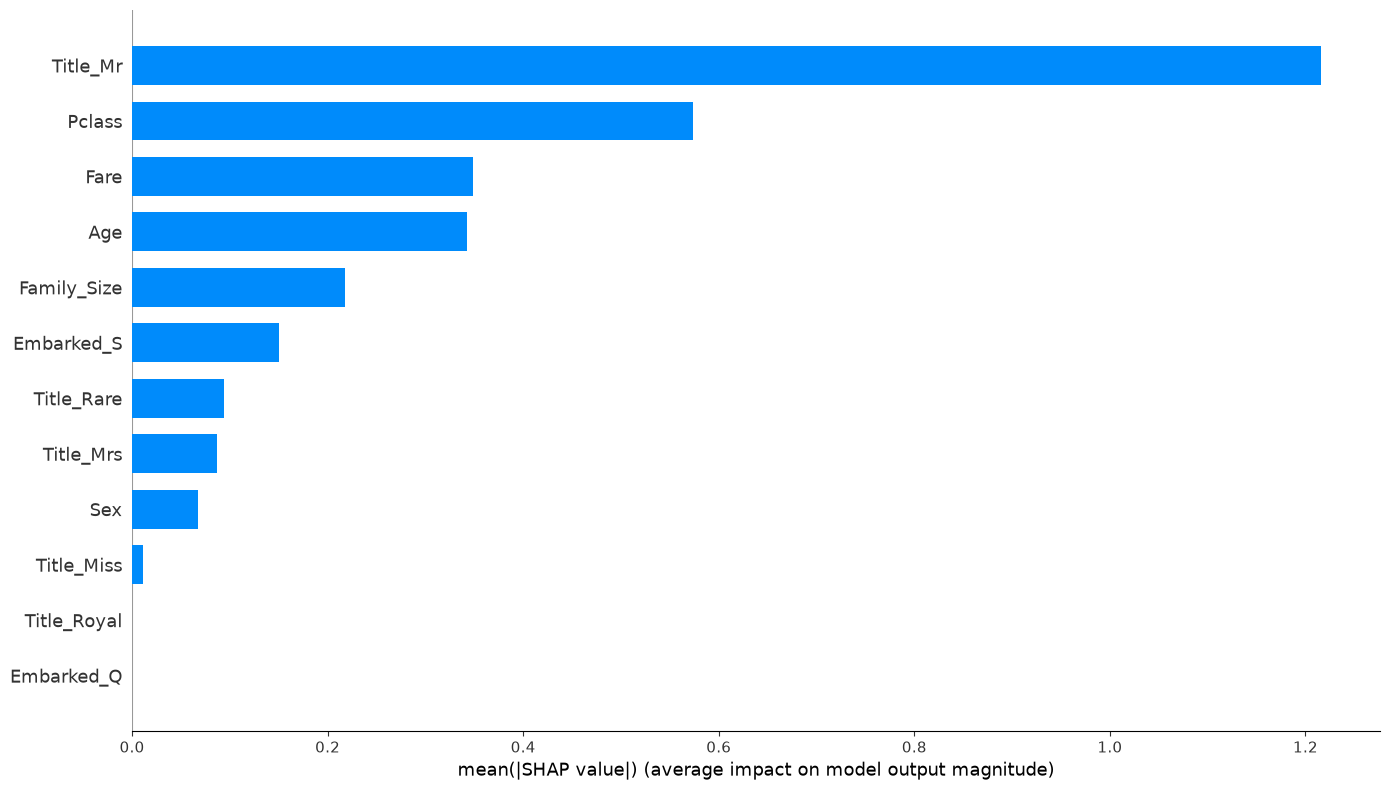

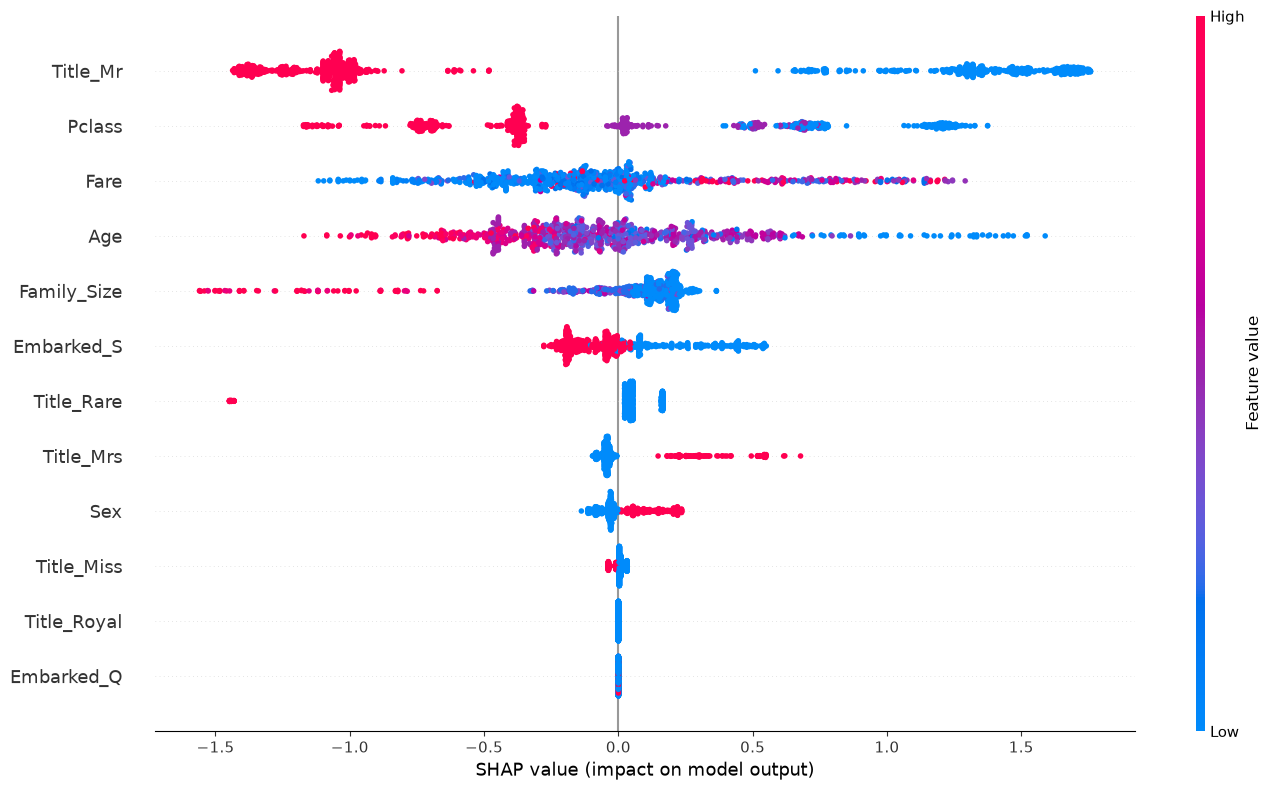

In [44]:
explainer = shap.TreeExplainer(accuracy_model)
shap_raw = explainer.shap_values(X)

if isinstance(shap_raw, list):
    shap_plot_values = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
elif hasattr(shap_raw, "values"):
    vals = shap_raw.values
    shap_plot_values = vals[..., 1] if getattr(vals, "ndim", 0) == 3 else vals
elif getattr(shap_raw, "ndim", 0) == 3:
    shap_plot_values = shap_raw[..., 1]
else:
    shap_plot_values = shap_raw

print("SHAP shape for plot:", getattr(shap_plot_values, "shape", "n/a"))

shap.summary_plot(
    shap_plot_values,
    X,
    plot_type="bar",
    max_display=15,
    plot_size=(14, 8),
    show=True,
)

shap.summary_plot(
    shap_plot_values,
    X,
    max_display=15,
    plot_size=(14, 8),
    show=True,
)


Итог к сожелению такойже на kagle получил 0.76555 попробую вернутся к работе с признаками упрощу Family_Size уберу мультиколинеарность, избавлюсь от выбросов в Fareтак же сделаю флаг о наличии Cabin


In [45]:
# 1. Убираем дублирующий признак Sex 
df_full_base = df_full_base.drop('Sex', axis=1)

# 2. Обрезаем выброс в цене билета (оставляем максимум на уровне 99% остальных пассажиров)
fare_cap = df_full_base['Fare'].quantile(0.99)
df_full_base['Fare'] = df_full_base['Fare'].clip(upper=fare_cap)

# 3. Превращаем размер семьи из чисел в категории
df_full_base['Family_Cat'] = pd.cut(df_full_base['Family_Size'], bins=[1, 2, 5, 20], labels=['Solo', 'Small', 'Large'])
df_full_base = df_full_base.drop('Family_Size', axis=1) # числовой больше не нужен

# 4. Добавляем флаг "Была ли каюта"
df_full_base['Has_Cabin'] = df_full_base['Cabin'].notna().astype(int)

df_full_base = pd.get_dummies(df_full_base, columns=['Title', 'Embarked', 'Family_Cat'], drop_first=True)

df_full_base = df_full_base.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)
df_full_base[['Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_Royal', 'Embarked_Q', 'Embarked_S', 'Family_Cat_Small', 'Family_Cat_Large']] = df_full_base[['Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_Royal', 'Embarked_Q', 'Embarked_S', 'Family_Cat_Small', 'Family_Cat_Large']].astype('int')


In [46]:
X = df_full_base[df_full_base['is_train']==1].drop(['Survived', 'is_train'], axis=1).copy()
y = df_full_base[df_full_base['is_train']==1]['Survived']
test_kagel = df_full_base[df_full_base['is_train']==0].drop(['Survived', 'is_train'], axis=1).copy()

In [47]:
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1.0, 1.5, 1.6, 2.0, 3.0] 
}


grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy', # Ищем максимальный accuracy
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)
print(f"Лучший accuracy: {grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Лучший accuracy: 0.8451
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'scale_pos_weight': 1.0}


In [48]:
# Достаем лучшие параметры
best_accuracy = grid_search.best_params_

# Создаем финальную модель
accuracy_model = XGBClassifier(
    **best_accuracy,              # Распаковываем словарь с лучшими параметрами
    random_state=42, 
    eval_metric='logloss', 
    use_label_encoder=False
)
accuracy_model.fit(X, y)

# 2. Делаем предсказания для Kaggle
kaggle_predictions = accuracy_model.predict(test_kagel).astype(int)

# 3. Формируем файл
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': kaggle_predictions
})

# 4. Сохраняем
submission.to_csv('titanic_accuracy_optimized_v3.csv', index=False)
print("Файл готов к отправке на Kaggle!")

Файл готов к отправке на Kaggle!


Модификация признаков (категоризация Family_Size, удаление Sex, обрезка выбросов в Fare) с XGBoost дала на Kaggle 0.75837. Результат снова ниже бенчмарка.
Гипотеза: алгоритм градиентного бустинга (XGBoost) слишком сложен для данного объема данных (891 строка) и продолжает переобучаться, несмотря на регуляризацию (max_depth).
Принято решение перейти к алгоритму Random Forest, который за счет бэггинга менее склонен к переобучению на малых выборках.

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,      # Много деревьев, но они простые
    max_depth=4,           
    min_samples_leaf=5,    # В каждом листе минимум 5 человек
    max_features='sqrt',   # При каждом разбиении смотреть только на часть фичей
    random_state=42,
    n_jobs=-1
)

print("Обучаем простой лес...")
rf_model.fit(X, y)

kaggle_predictions = rf_model.predict(test_kagel).astype(int)


submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': kaggle_predictions
})

submission.to_csv('titanic_simple_rf.csv', index=False)

Обучаем простой лес...


Успешный результат:

Обучение простого Random Forest (max_depth=4, min_samples_leaf=5) позволило получить на Kaggle 0.77751. Базовый порог пройден.
Для проверки лимита алгоритма был произведен GridSearch по параметрам леса. Лучшие параметры CV: max_depth=5.
Применение найденных параметров снизило Score на Kaggle до 0.77272.
Итоговый вывод по моделированию: Увеличение глубины деревьев леса (с 4 до 5) привело к локальному переобучению. Наилучший результат на публичном лидерборде показала модель с жесткими ограничениями сложности (мелкие деревья). Дальнейший рост точности требует не тюнинга гиперпараметров, а создания более информативных признаков (Feature Engineering 2.0).

In [50]:
param_grid = {
    'max_depth': [3, 4, 5],           # Только вокруг текущей 4-ки
    'min_samples_leaf': [4, 5, 7],    # Только вокруг текущей 5-ки
    'max_features': ['sqrt', 0.5]     # Доля фичей для разбиения
}

rf_base = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

grid = GridSearchCV(rf_base, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X, y) # Обязательно на полном X!

print(f"Лучший скор: {grid.best_score_:.4f}")
print(f"Параметры: {grid.best_params_}")

Лучший скор: 0.8372
Параметры: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5}


In [51]:
rf_model = RandomForestClassifier(
    n_estimators=300,      # Много деревьев, но они простые
    max_depth=5,           # МАКСИМАЛЬНО мелкие деревья (4 уровня)
    min_samples_leaf=5,    # В каждом листе минимум 5 человек
    max_features='sqrt',   # При каждом разбиении смотреть только на часть фичей
    random_state=42,
    n_jobs=-1
)

print("Обучаем простой лес...")
rf_model.fit(X, y)

kaggle_predictions = rf_model.predict(test_kagel).astype(int)


submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': kaggle_predictions
})

submission.to_csv('titanic_simple_rf_v2.csv', index=False)

Обучаем простой лес...


Score: 0.77272 и мы ухудшили результ, возможно что отличие от моего в том что тут используются более сложные деревья 


Classification Report on Test Set:
              precision    recall  f1-score   support

 No Survived       0.85      0.92      0.88       549
    Survived       0.85      0.74      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.84       891
weighted avg       0.85      0.85      0.85       891



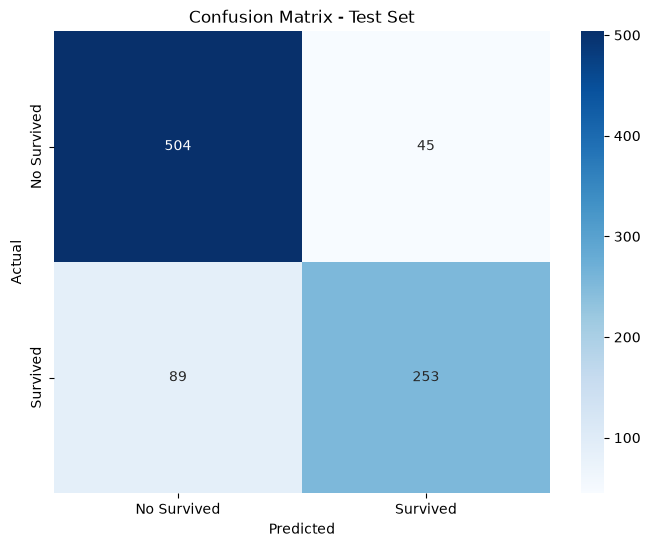

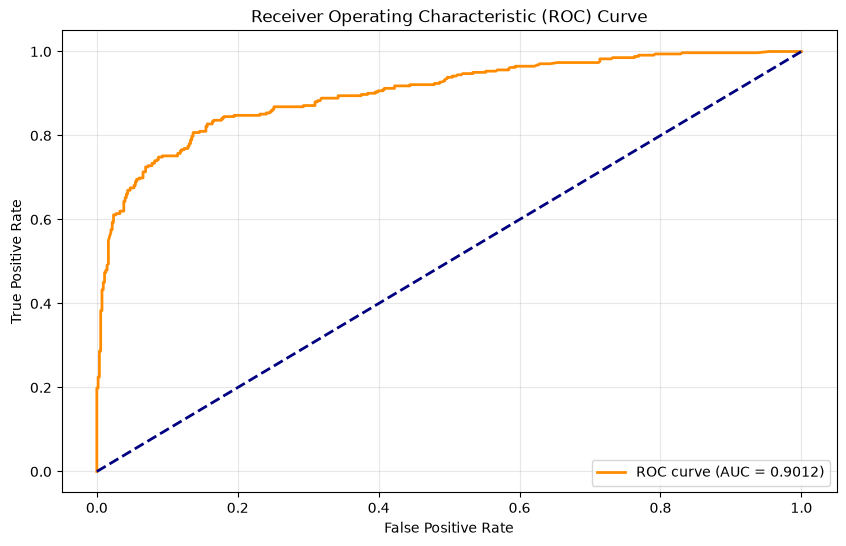

In [52]:
y_test_pred = rf_model.predict(X)
y_test_proba = rf_model.predict_proba(X)[:, 1]


print("Classification Report on Test Set:")
print(classification_report(y, y_test_pred, target_names=['No Survived', 'Survived']))

cm = confusion_matrix(y, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Survived', 'Survived'], 
            yticklabels=['No Survived', 'Survived'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, thresholds = roc_curve(y, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


SHAP shape for plot: (891, 13)


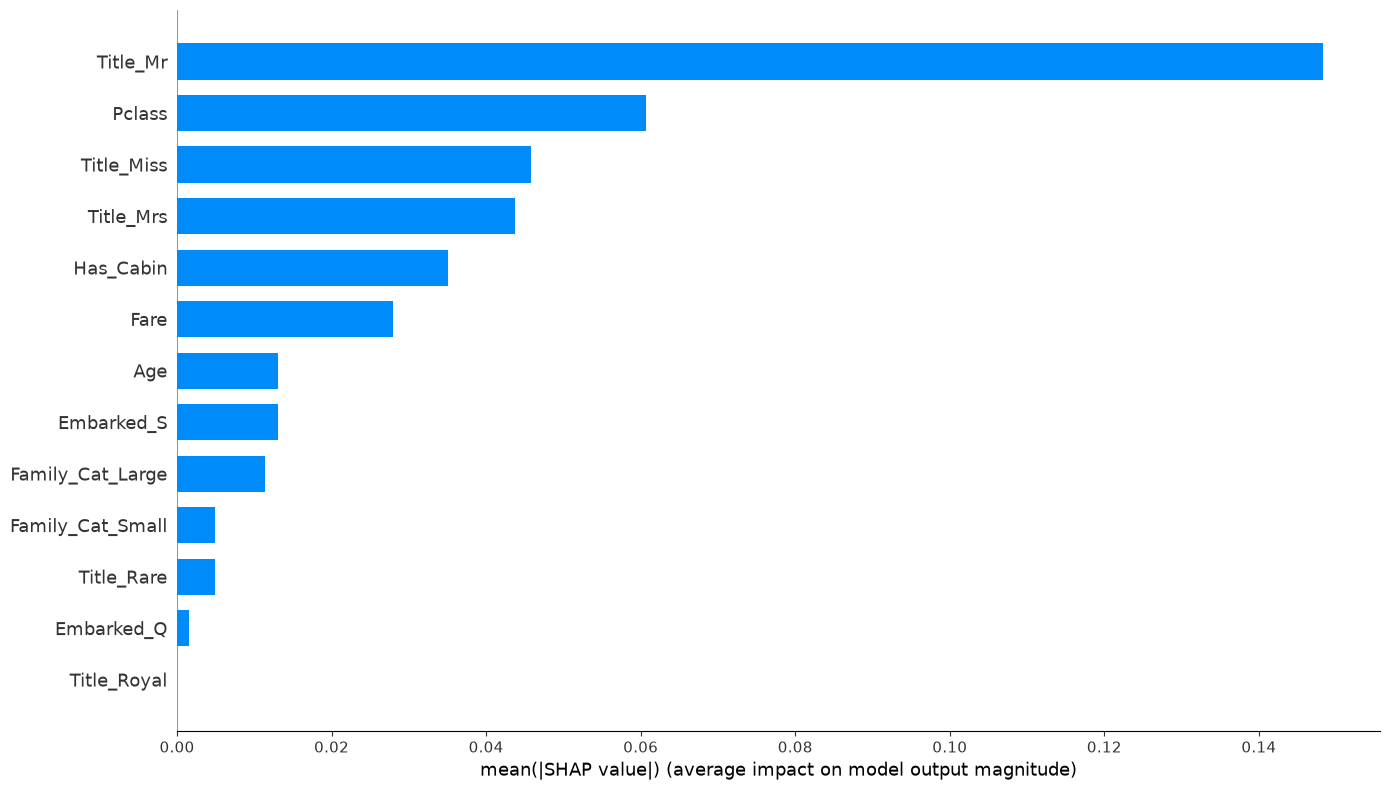

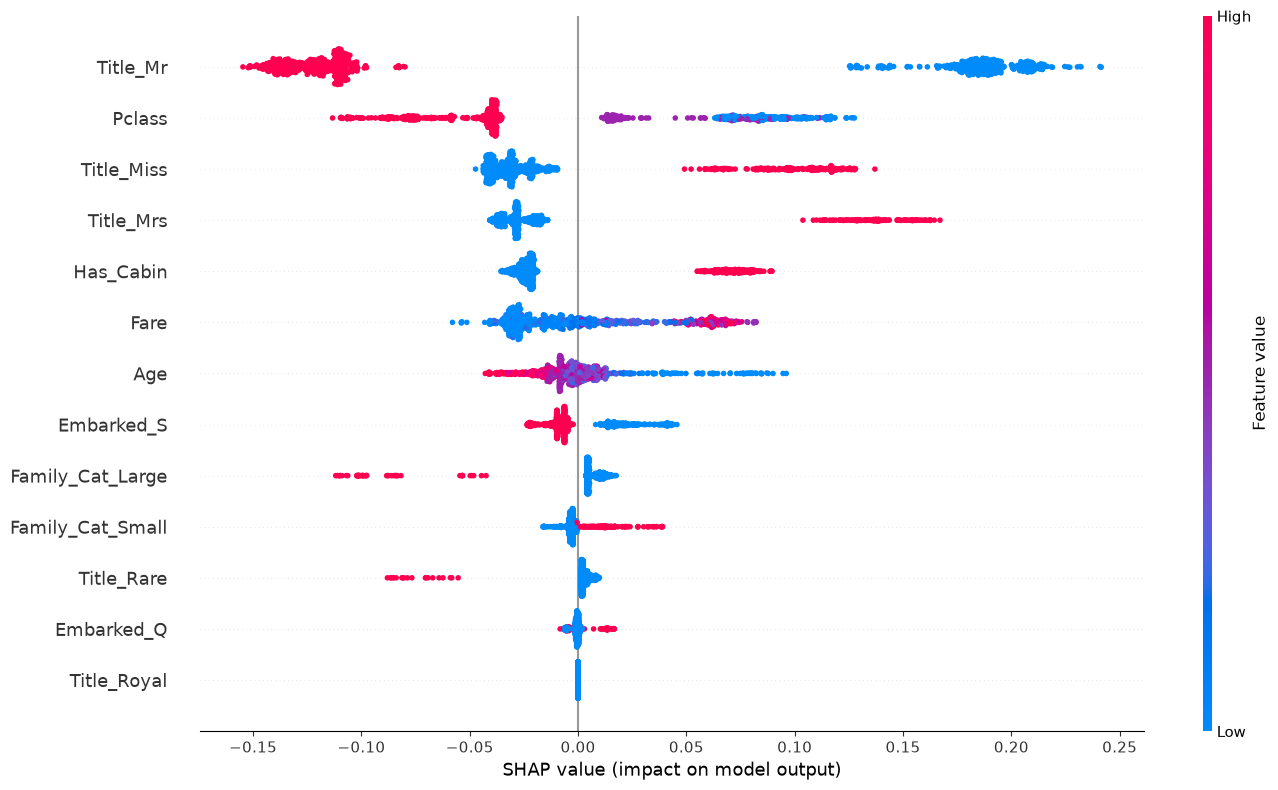

In [53]:
explainer = shap.TreeExplainer(rf_model)
shap_raw = explainer.shap_values(X)

if isinstance(shap_raw, list):
    shap_plot_values = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
elif hasattr(shap_raw, "values"):
    vals = shap_raw.values
    shap_plot_values = vals[..., 1] if getattr(vals, "ndim", 0) == 3 else vals
elif getattr(shap_raw, "ndim", 0) == 3:
    shap_plot_values = shap_raw[..., 1]
else:
    shap_plot_values = shap_raw

print("SHAP shape for plot:", getattr(shap_plot_values, "shape", "n/a"))

shap.summary_plot(
    shap_plot_values,
    X,
    plot_type="bar",
    max_display=15,
    plot_size=(14, 8),
    show=True,
)

shap.summary_plot(
    shap_plot_values,
    X,
    max_display=15,
    plot_size=(14, 8),
    show=True,
)


## Итоговый вывод по результатам исследования
1. Цель и контекст задачи
В рамках данного исследования решалась задача бинарной классификации — построение модели машинного обучения для предсказания выживаемости пассажиров Титаника. Датасет представляет собой классический пример задачи с небольшим объемом данных (891 запись в обучающей выборке), наличием пропусков и необходимостью ручного конструирования признаков (Feature Engineering).

2. Ключевые инсайты из разведывательного анализа (EDA)
Анализ подтвердил исторические закономерности: наибольшие шансы на спасение имели женщины, дети и пассажиры первого класса. Однако более глубокий анализ позволил выявить неочевидные паттерны:

Социальный статус, заложенный в обращении (Title), сильнее влияет на выживаемость, чем просто пол. Например, замужние женщины (Mrs) выживали чаще незамужних (Miss), а обращение "Master" (мальчики) давало шансы на спасение сопоставимые с женскими.
Размер семьи имеет нелинейную зависимость с выживаемостью: одиночки и большие семьи погибали чаще, чем семьи из 2-4 человек.
Наличие данных о каюте (Cabin) само по себе является мощным предиктором, так как отсутствие этого поля сильно коррелирует с низким классом и гибелью пассажира.
3. Опыт моделирования и выбор метрик
В работе были протестированы различные алгоритмы: логистическая регрессия, Random Forest и XGBoost.
Особенностью задачи стал конфликт между бизнес-логикой и метрикой соревнования. С точки зрения реальной задачи (спасение жизней) критически важной метрикой является Recall (минимизация ложных отрицательных срабатываний — мы не должны предсказать смерть тому, кто выживет). Оптимизация XGBoost на Recall позволила достичь показателя в 0.87, хотя и ценой падения точности (Precision). Однако Kaggle оценивает решение по метрике Accuracy, что потребовало отдельного подхода к настройке моделей.

4. Проблема переобучения и "Baseline paradox"
Важным практическим уроком стало столкновение с переобучением сложных моделей. Базовое эвристическое правило «если пол женский — выжил, иначе — погиб» дает Accuracy на Kaggle равную 0.7655. Начальные реализации XGBoost с глубоким подбором гиперпараметров проигрывали этому простейшему правилу, несмотря на высокий локальный ROC-AUC (0.896). Это произошло из-за того, что на малом датасете бустинг начал подстраиваться под шум. Решением стала регуляризация: переход на простой Random Forest с мелкими деревьями (max_depth=4-5), который показал лучшую обобщающую способность и пробил потолок базового правила, достигнув Score: 0.77751 на Kaggle.
